## Imports

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display
from scipy.stats import randint, uniform
from sklearn import set_config
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

## Load data

In [2]:
data_path = Path("data/preprocessed_credit_risk.csv")
df = pd.read_csv(data_path)

In [3]:
df.head()

,age,income,loanamount,creditscore,monthsemployed,numcreditlines,interestrate,loanterm,dtiratio,education,employmenttype,maritalstatus,hasmortgage,hasdependents,loanpurpose,hascosigner,default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High_School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor,Unemployed,Divorced,No,Yes,Auto,No,0


## Inspect the preprocessed data

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   age             255347 non-null  int64  
 1   income          255347 non-null  int64  
 2   loanamount      255347 non-null  int64  
 3   creditscore     255347 non-null  int64  
 4   monthsemployed  255347 non-null  int64  
 5   numcreditlines  255347 non-null  int64  
 6   interestrate    255347 non-null  float64
 7   loanterm        255347 non-null  int64  
 8   dtiratio        255347 non-null  float64
 9   education       255347 non-null  str    
 10  employmenttype  255347 non-null  str    
 11  maritalstatus   255347 non-null  str    
 12  hasmortgage     255347 non-null  str    
 13  hasdependents   255347 non-null  str    
 14  loanpurpose     255347 non-null  str    
 15  hascosigner     255347 non-null  str    
 16  default         255347 non-null  int64  
dtypes: float64(2), int64(

In [5]:
data_overview = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "duplicate_rows": int(df.duplicated().sum()),
    "missing_values": int(df.isna().sum().sum()),
})
display(data_overview)

rows              255347
columns               17
duplicate_rows         0
missing_values         0
dtype: int64

In [6]:
column_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique_values": df.nunique(),
})
display(column_summary)

,dtype,missing,unique_values
age,int64,0,52
income,int64,0,114620
loanamount,int64,0,158729
creditscore,int64,0,550
monthsemployed,int64,0,120
numcreditlines,int64,0,4
interestrate,float64,0,2301
loanterm,int64,0,5
dtiratio,float64,0,81
education,str,0,4


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,255347.0,NaN,NaN,NaN,43.498306,14.990258,18.0,31.0,43.0,56.0,69.0
income,255347.0,NaN,NaN,NaN,82499.304597,38963.013729,15000.0,48825.5,82466.0,116219.0,149999.0
loanamount,255347.0,NaN,NaN,NaN,127578.865512,70840.706142,5000.0,66156.0,127556.0,188985.0,249999.0
creditscore,255347.0,NaN,NaN,NaN,574.264346,158.903867,300.0,437.0,574.0,712.0,849.0
monthsemployed,255347.0,NaN,NaN,NaN,59.541976,34.643376,0.0,30.0,60.0,90.0,119.0
numcreditlines,255347.0,NaN,NaN,NaN,2.501036,1.117018,1.0,2.0,2.0,3.0,4.0
interestrate,255347.0,NaN,NaN,NaN,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
loanterm,255347.0,NaN,NaN,NaN,36.025894,16.96933,12.0,24.0,36.0,48.0,60.0
dtiratio,255347.0,NaN,NaN,NaN,0.500212,0.230917,0.1,0.3,0.5,0.7,0.9
education,255347,4,Bachelor,64366,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
if "default" not in df.columns or df["default"].isna().any():
    raise ValueError("The data must contain a non-missing 'default' target.")
if set(df["default"].unique()) != {0, 1}:
    raise ValueError("The target must contain both 0 (no default) and 1 (default).")

class_distribution = pd.DataFrame({
    "count": df["default"].value_counts().sort_index(),
    "proportion": df["default"].value_counts(normalize=True).sort_index(),
})
display(class_distribution)

,count,proportion
default,,
0,225694,0.883872
1,29653,0.116128


## Configuration

In [9]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_RECALL = 0.70
N_JOBS = -1
RF_MAX_DEPTH = 24
RUN_RF_DEPTH_SEARCH = False
MODEL_PATH = Path("final_credit_risk_xgboost.pkl")

set_config(transform_output="pandas")

cv_evaluation = StratifiedKFold(n_splits=5, shuffle=False)
cv_oof = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

## reusable utilities

In [10]:
def specificity_score(y_true, predictions):
    tn, fp, _, _ = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return tn / (tn + fp) if tn + fp else np.nan


def get_scores(model, X):
    """Return scores for default (class 1)."""
    classes = np.asarray(model.classes_)
    if set(classes) != {0, 1}:
        raise ValueError("Expected binary classes 0 and 1.")
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, np.flatnonzero(classes == 1)[0]]
    scores = model.decision_function(X)
    return scores if classes[1] == 1 else -scores


def evaluate_predictions(y_true, predictions, scores):
    """Evaluate binary predictions and continuous class-1 scores."""
    both_classes = np.unique(y_true).size == 2
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "specificity": specificity_score(y_true, predictions),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores) if both_classes else np.nan,
        "average_precision": average_precision_score(y_true, scores) if both_classes else np.nan,
    }


def get_errors(model, X, y, threshold=None):
    """Use the estimator's predictions unless an explicit threshold is supplied."""
    scores = get_scores(model, X)
    predictions = model.predict(X) if threshold is None else (scores >= threshold).astype(int)
    return evaluate_predictions(y, predictions, scores)


def get_avg_cv_errors(cv_result):
    return {
        metric: float(np.mean(cv_result[f"test_{metric}"]))
        for metric in METRIC_NAMES
    }


def log_error(model_name, errors, eval_set, perf_df):
    columns = [f"{eval_set}_{metric}" for metric in METRIC_NAMES]
    perf_df.loc[model_name, columns] = [errors[metric] for metric in METRIC_NAMES]


def select_threshold(y_true, scores, target_recall=0.70):
    """Maximize precision subject to the requested recall, using validation scores."""
    if not 0 < target_recall <= 1:
        raise ValueError("target_recall must be greater than 0 and at most 1.")
    if set(np.unique(y_true)) != {0, 1}:
        raise ValueError("Threshold selection requires both target classes.")
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    table = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
    })
    denominator = table["precision"] + table["recall"]
    table["f1"] = (2 * table["precision"] * table["recall"] / denominator).fillna(0)
    eligible = table.loc[table["recall"] >= target_recall]
    if eligible.empty:
        raise ValueError("No threshold meets the requested recall.")
    selected = eligible.sort_values(
        ["precision", "f1", "threshold"], ascending=[False, False, False]
    ).iloc[0]
    return table, selected


def summarize_thresholds(table, target_recalls=(0.50, 0.60, 0.70, 0.80)):
    indices = [
        np.abs(table["recall"].to_numpy() - target).argmin()
        for target in target_recalls
    ]
    return table.iloc[indices].drop_duplicates().sort_values("recall").reset_index(drop=True)


def plot_confusion_matrix(y_true, predictions, model_name, split="test"):
    ConfusionMatrixDisplay.from_predictions(
        y_true, predictions, labels=[0, 1],
        display_labels=["No Default", "Default"], values_format="d", cmap="Blues",
    )
    plt.title(f"{model_name} Confusion Matrix [{split.title()} Set]")
    plt.tight_layout()
    plt.show()

In [11]:
scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "specificity": make_scorer(specificity_score),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}
METRIC_NAMES = tuple(scoring_metrics)

perf_df = pd.DataFrame(
    columns=[f"{split}_{metric}" for split in ("train", "cv", "test") for metric in METRIC_NAMES],
    dtype=float,
)

## Train/test split

In [12]:
X = df.drop(columns="default")
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=TEST_SIZE, random_state=RANDOM_STATE,
)

In [13]:
split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "features": [X_train.shape[1], X_test.shape[1]],
    "default_proportion": [y_train.mean(), y_test.mean()],
}, index=["Train", "Test"])
display(split_summary)

,rows,features,default_proportion
Train,204277,16,0.116127
Test,51070,16,0.116135


##  preprocessing

In [14]:
categorical_cols = X_train.select_dtypes(exclude="number").columns.to_list()
category_transformer = ColumnTransformer(
    [("cat_encoder", OneHotEncoder(sparse_output=False, drop="if_binary"), categorical_cols)],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

## Random Forest 

In [15]:
rf_unrestricted_pipeline = make_pipeline(
    clone(category_transformer),
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS),
)
rf_unrestricted_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','income','loanamount',...,'hasdependents','loanpurpose', 'hascosigner']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

## depth inspection and optional search

In [16]:
tree_depths = [tree.get_depth() for tree in rf_unrestricted_pipeline[-1].estimators_]
display(pd.Series({
    "minimum_depth": min(tree_depths),
    "maximum_depth": max(tree_depths),
    "average_depth": np.mean(tree_depths),
}))

minimum_depth    30.00
maximum_depth    38.00
average_depth    33.43
dtype: float64

In [17]:
if RUN_RF_DEPTH_SEARCH:
    rf_depth_search = GridSearchCV(
        estimator=clone(rf_unrestricted_pipeline),
        param_grid={"randomforestclassifier__max_depth": [24, 28, 32, 36, None]},
        scoring=scoring_metrics,
        refit="recall",
        return_train_score=True,
        cv=cv_evaluation,
        n_jobs=N_JOBS,
        pre_dispatch=N_JOBS,
        verbose=1,
    )
    rf_depth_search.fit(X_train, y_train)
    RF_MAX_DEPTH = rf_depth_search.best_params_["randomforestclassifier__max_depth"]
    rf_depth_results = pd.DataFrame(rf_depth_search.cv_results_)

In [18]:
if RUN_RF_DEPTH_SEARCH:
    depth_columns = [
        "param_randomforestclassifier__max_depth",
        "rank_test_recall", "mean_test_recall", "std_test_recall",
        "mean_train_recall", "std_train_recall", "mean_test_accuracy",
        "mean_train_accuracy", "mean_test_precision", "mean_train_precision",
        "mean_test_f1", "mean_test_roc_auc",
    ]
    display(rf_depth_results[depth_columns].sort_values(["rank_test_recall", "std_test_recall"]))

In [19]:
if RUN_RF_DEPTH_SEARCH:
    positions = np.arange(len(rf_depth_results))
    depth_labels = [
        "None" if pd.isna(depth) else str(int(depth))
        for depth in rf_depth_results["param_randomforestclassifier__max_depth"]
    ]
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric in zip(axes, ["recall", "precision", "accuracy"]):
        ax.plot(positions, rf_depth_results[f"mean_train_{metric}"], marker="o", label="Train")
        ax.plot(positions, rf_depth_results[f"mean_test_{metric}"], marker="o", label="Validation")
        ax.set_xticks(positions, depth_labels)
        ax.set_xlabel("Maximum tree depth")
        ax.set_ylabel(metric.title())
        ax.legend()
    plt.tight_layout()
    plt.show()

## Random Forest retrain and cross-validation

In [20]:
rf_model = RandomForestClassifier(
    max_depth=RF_MAX_DEPTH, random_state=RANDOM_STATE, n_jobs=N_JOBS,
)
rf_pipeline = make_pipeline(clone(category_transformer), rf_model)

In [21]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','income','loanamount',...,'hasdependents','loanpurpose', 'hascosigner']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [22]:
rf_train_errors = get_errors(rf_pipeline, X_train, y_train)
log_error("RF Model", rf_train_errors, "train", perf_df)
display(pd.Series(rf_train_errors))

accuracy             0.999794
balanced_accuracy    0.999115
precision            1.000000
recall               0.998229
specificity          1.000000
f1                   0.999114
roc_auc              1.000000
average_precision    1.000000
dtype: float64

In [23]:
rf_cv_result = cross_validate(
    rf_pipeline, X_train, y_train, scoring=scoring_metrics,
    cv=cv_evaluation, n_jobs=N_JOBS,
)
rf_avg_cv_errors = get_avg_cv_errors(rf_cv_result)
log_error("RF Model", rf_avg_cv_errors, "cv", perf_df)
display(pd.Series(rf_avg_cv_errors))

accuracy             0.885435
balanced_accuracy    0.514486
precision            0.636785
recall               0.031321
specificity          0.997652
f1                   0.059703
roc_auc              0.729104
average_precision    0.297347
dtype: float64

## Baseline XGBoost training and cross-validation

In [24]:
baseline_xgb_model = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss", tree_method="hist",
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=N_JOBS,
)
baseline_xgb_pipeline = make_pipeline(clone(category_transformer), baseline_xgb_model)

In [25]:
baseline_xgb_cv_result = cross_validate(
    baseline_xgb_pipeline, X_train, y_train, cv=cv_evaluation,
    scoring=scoring_metrics, return_train_score=True, n_jobs=N_JOBS,
)
baseline_xgb_avg_cv_errors = get_avg_cv_errors(baseline_xgb_cv_result)
log_error("Baseline XGBoost (default cutoff)", baseline_xgb_avg_cv_errors, "cv", perf_df)
display(pd.Series(baseline_xgb_avg_cv_errors))

accuracy             0.886541
balanced_accuracy    0.526866
precision            0.622618
recall               0.058385
specificity          0.995348
f1                   0.106750
roc_auc              0.753422
average_precision    0.321549
dtype: float64

In [26]:
baseline_xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','income','loanamount',...,'hasdependents','loanpurpose', 'hascosigner']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

In [27]:
baseline_xgb_train_errors = get_errors(baseline_xgb_pipeline, X_train, y_train)
log_error("Baseline XGBoost (default cutoff)", baseline_xgb_train_errors, "train", perf_df)
display(pd.Series(baseline_xgb_train_errors))

accuracy             0.887281
balanced_accuracy    0.528017
precision            0.661560
recall               0.060071
specificity          0.995962
f1                   0.110141
roc_auc              0.766283
average_precision    0.342659
dtype: float64

## Baseline XGBoost threshold selection

In [28]:
baseline_xgb_oof_probabilities = cross_val_predict(
    baseline_xgb_pipeline, X_train, y_train, cv=cv_oof,
    method="predict_proba", n_jobs=N_JOBS,
)[:, 1]

In [29]:
baseline_xgb_threshold_results, baseline_xgb_threshold_row = select_threshold(
    y_train, baseline_xgb_oof_probabilities, TARGET_RECALL,
)
baseline_xgb_threshold = float(baseline_xgb_threshold_row["threshold"])
display(baseline_xgb_threshold_row)

threshold    0.110747
precision    0.219063
recall       0.700194
f1           0.333718
Name: 127375, dtype: float64

In [30]:
baseline_xgb_threshold_summary = summarize_thresholds(baseline_xgb_threshold_results)
display(baseline_xgb_threshold_summary)

,threshold,precision,recall,f1
0,0.171261,0.286117,0.500000,0.363963
1,0.139555,0.251542,0.599992,0.354474
2,0.110767,0.219032,0.699983,0.333658
3,0.084939,0.189271,0.800017,0.306119


## XGBoost hyperparameter search

In [31]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
imbalance_ratio = negative_count / positive_count
display(pd.Series({
    "negative_samples": negative_count,
    "positive_samples": positive_count,
    "imbalance_ratio": imbalance_ratio,
}))

negative_samples    180555.000000
positive_samples     23722.000000
imbalance_ratio          7.611289
dtype: float64

In [32]:
xgb_search_model = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss", tree_method="hist",
    random_state=RANDOM_STATE, n_jobs=N_JOBS,
)
xgb_search_pipeline = make_pipeline(clone(category_transformer), xgb_search_model)

In [33]:
xgb_parameter_distributions = {
    "xgbclassifier__n_estimators": randint(150, 401),
    "xgbclassifier__max_depth": randint(3, 9),
    "xgbclassifier__learning_rate": uniform(0.02, 0.13),
    "xgbclassifier__min_child_weight": randint(1, 9),
    "xgbclassifier__gamma": uniform(0.0, 0.5),
    "xgbclassifier__subsample": uniform(0.7, 0.3),
    "xgbclassifier__colsample_bytree": uniform(0.7, 0.3),
    "xgbclassifier__reg_alpha": uniform(0.0, 0.5),
    "xgbclassifier__reg_lambda": uniform(0.5, 1.5),
    "xgbclassifier__scale_pos_weight": [
        1.0, imbalance_ratio * 0.50, imbalance_ratio * 0.75, imbalance_ratio,
    ],
}

In [34]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_search_pipeline,
    param_distributions=xgb_parameter_distributions,
    n_iter=12,
    scoring=scoring_metrics,
    refit="average_precision",
    cv=cv_search,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    pre_dispatch=2,
    verbose=1,
    return_train_score=True,
)
xgb_random_search.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'xgbclassifier__colsample_bytree': <scipy.stats....x756fc1046fc0>, 'xgbclassifier__gamma': <scipy.stats....x756fc10978c0>, 'xgbclassifier__learning_rate': <scipy.stats....x756fc1096060>, 'xgbclassifier__max_depth': <scipy.stats....x756fc739eba0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'average_precision': 'average_precision', 'balanced_accuracy': 'balanced_accuracy', 'f1': make_scorer(f...ro_division=0), ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) spli

In [35]:
best_xgb_pipeline = xgb_random_search.best_estimator_
display(pd.Series(xgb_random_search.best_params_, name="best_value"))
display(pd.Series({"best_cv_average_precision": xgb_random_search.best_score_}))

xgbclassifier__colsample_bytree      0.880335
xgbclassifier__gamma                 0.354036
xgbclassifier__learning_rate         0.022676
xgbclassifier__max_depth             4.000000
xgbclassifier__min_child_weight      8.000000
xgbclassifier__n_estimators        385.000000
xgbclassifier__reg_alpha             0.469276
xgbclassifier__reg_lambda            0.501168
xgbclassifier__scale_pos_weight      7.611289
xgbclassifier__subsample             0.755021
Name: best_value, dtype: float64

best_cv_average_precision    0.320691
dtype: float64

In [36]:
xgb_search_results = pd.DataFrame(xgb_random_search.cv_results_)
search_columns = [
    "rank_test_average_precision", "mean_test_average_precision",
    "mean_test_roc_auc", "mean_test_recall", "mean_test_precision", "mean_test_f1",
    "param_xgbclassifier__scale_pos_weight", "param_xgbclassifier__max_depth",
    "param_xgbclassifier__n_estimators", "param_xgbclassifier__learning_rate",
]
display(xgb_search_results[search_columns].sort_values("rank_test_average_precision").head(10))

,rank_test_average_precision,mean_test_average_precision,mean_test_roc_auc,mean_test_recall,mean_test_precision,mean_test_f1,param_xgbclassifier__scale_pos_weight,param_xgbclassifier__max_depth,param_xgbclassifier__n_estimators,param_xgbclassifier__learning_rate
1,1,0.320691,0.752634,0.676587,0.225430,0.338181,7.611289,4,385,0.022676
2,2,0.319556,0.752568,0.682320,0.225150,0.338577,7.611289,3,208,0.076153
4,3,0.319374,0.751157,0.562221,0.261450,0.356918,5.708467,4,239,0.093227
5,4,0.317909,0.751146,0.380575,0.330771,0.353912,3.805645,3,199,0.042537
3,5,0.315878,0.749043,0.071158,0.579311,0.126735,1.000000,6,398,0.045958
10,6,0.314801,0.748255,0.519223,0.274214,0.358889,5.708467,8,186,0.032403
9,7,0.312835,0.746881,0.072296,0.564515,0.128169,1.000000,5,272,0.112474
8,8,0.310420,0.744024,0.605387,0.239794,0.343519,7.611289,7,238,0.058516
0,9,0.299670,0.735161,0.467457,0.277463,0.348229,5.708467,7,252,0.115159
6,10,0.295724,0.731192,0.563949,0.241631,0.338305,7.611289,6,351,0.129497


## Optimized XGBoost threshold selection

In [37]:
optimized_xgb_oof_probabilities = cross_val_predict(
    best_xgb_pipeline, X_train, y_train, cv=cv_oof,
    method="predict_proba", n_jobs=N_JOBS,
)[:, 1]

In [38]:
optimized_threshold_results, optimized_threshold_row = select_threshold(
    y_train, optimized_xgb_oof_probabilities, TARGET_RECALL,
)
optimized_threshold = float(optimized_threshold_row["threshold"])
display(optimized_threshold_row)

threshold    0.484951
precision    0.218949
recall       0.700152
f1           0.333581
Name: 127579, dtype: float64

## Balanced Random Forest threshold selection

In [39]:
balanced_rf_pipeline = clone(rf_pipeline).set_params(
    randomforestclassifier__class_weight="balanced",
)

In [40]:
rf_oof_probabilities = cross_val_predict(
    balanced_rf_pipeline, X_train, y_train, cv=cv_oof,
    method="predict_proba", n_jobs=N_JOBS,
)[:, 1]

In [41]:
rf_threshold_results, rf_best_threshold_row = select_threshold(
    y_train, rf_oof_probabilities, TARGET_RECALL,
)
rf_optimal_threshold = float(rf_best_threshold_row["threshold"])
display(rf_best_threshold_row)

threshold    0.227490
precision    0.208196
recall       0.700110
f1           0.320949
Name: 40116, dtype: float64

In [42]:
balanced_rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','income','loanamount',...,'hasdependents','loanpurpose', 'hascosigner']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

## Training-only comparison

Compare the baseline XGBoost as well as the tuned models.

In [43]:
oof_comparison = pd.DataFrame({
    "Baseline XGBoost": {
        "threshold": baseline_xgb_threshold,
        **evaluate_predictions(y_train, (baseline_xgb_oof_probabilities >= baseline_xgb_threshold).astype(int), baseline_xgb_oof_probabilities),
    },
    "Optimized XGBoost": {
        "threshold": optimized_threshold,
        **evaluate_predictions(y_train, (optimized_xgb_oof_probabilities >= optimized_threshold).astype(int), optimized_xgb_oof_probabilities),
    },
    "Balanced Random Forest": {
        "threshold": rf_optimal_threshold,
        **evaluate_predictions(y_train, (rf_oof_probabilities >= rf_optimal_threshold).astype(int), rf_oof_probabilities),
    },
}).T
display(oof_comparison)

,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,average_precision
Baseline XGBoost,0.110747,0.675318,0.686122,0.219063,0.700194,0.672050,0.333718,0.753413,0.321519
Optimized XGBoost,0.484951,0.675137,0.686001,0.218949,0.700152,0.671851,0.333581,0.753475,0.321607
Balanced Random Forest,0.227490,0.655972,0.675141,0.208196,0.700110,0.650173,0.320949,0.737890,0.297681


## Test evaluation

The performance table below uses the models' default 0.5 cutoff. 

In [44]:
rf_test_errors = get_errors(rf_pipeline, X_test, y_test)
baseline_xgb_default_test_errors = get_errors(baseline_xgb_pipeline, X_test, y_test)
log_error("RF Model", rf_test_errors, "test", perf_df)
log_error("Baseline XGBoost (default cutoff)", baseline_xgb_default_test_errors, "test", perf_df)
display(perf_df)

,train_accuracy,train_balanced_accuracy,train_precision,train_recall,train_specificity,train_f1,train_roc_auc,train_average_precision,cv_accuracy,cv_balanced_accuracy,...,cv_roc_auc,cv_average_precision,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_specificity,test_f1,test_roc_auc,test_average_precision
RF Model,0.999794,0.999115,1.00000,0.998229,1.000000,0.999114,1.000000,1.000000,0.885435,0.514486,...,0.729104,0.297347,0.885804,0.516547,0.653251,0.035576,0.997519,0.067477,0.737445,0.308992
Baseline XGBoost (default cutoff),0.887281,0.528017,0.66156,0.060071,0.995962,0.110141,0.766283,0.342659,0.886541,0.526866,...,0.753422,0.321549,0.886744,0.526964,0.634862,0.058338,0.995591,0.106856,0.758987,0.332780


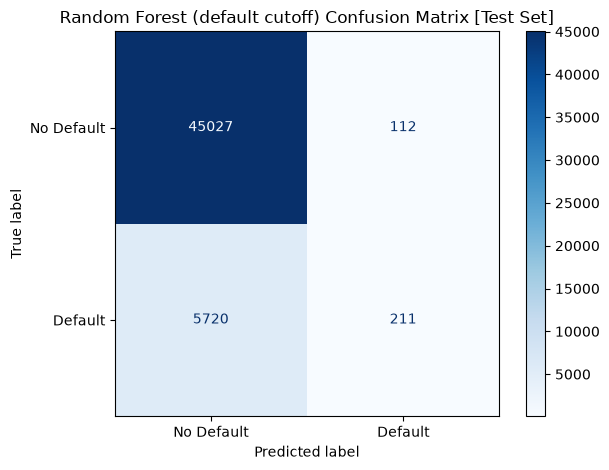

In [45]:
plot_confusion_matrix(y_test, rf_pipeline.predict(X_test), "Random Forest (default cutoff)")

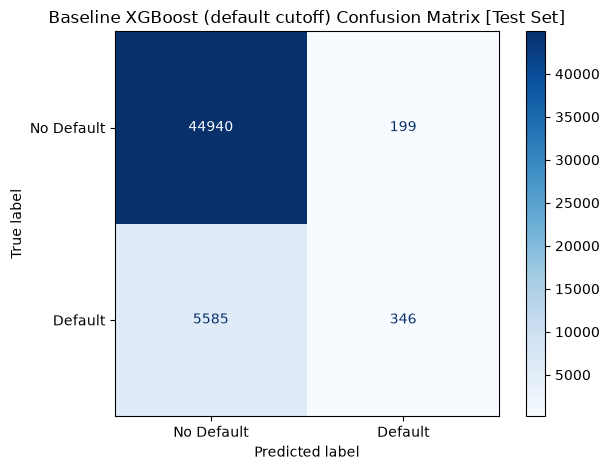

In [46]:
plot_confusion_matrix(y_test, baseline_xgb_pipeline.predict(X_test), "Baseline XGBoost (default cutoff)")

## Baseline XGBoost test evaluation at the selected threshold

In [47]:
baseline_xgb_test_probabilities = get_scores(baseline_xgb_pipeline, X_test)
baseline_xgb_test_predictions = (baseline_xgb_test_probabilities >= baseline_xgb_threshold).astype(int)
baseline_xgb_test_results = {
    "threshold": baseline_xgb_threshold,
    **evaluate_predictions(y_test, baseline_xgb_test_predictions, baseline_xgb_test_probabilities),
}
display(pd.Series(baseline_xgb_test_results))

threshold            0.110747
accuracy             0.673683
balanced_accuracy    0.689528
precision            0.219856
recall               0.710167
specificity          0.668889
f1                   0.335765
roc_auc              0.758987
average_precision    0.332780
dtype: float64

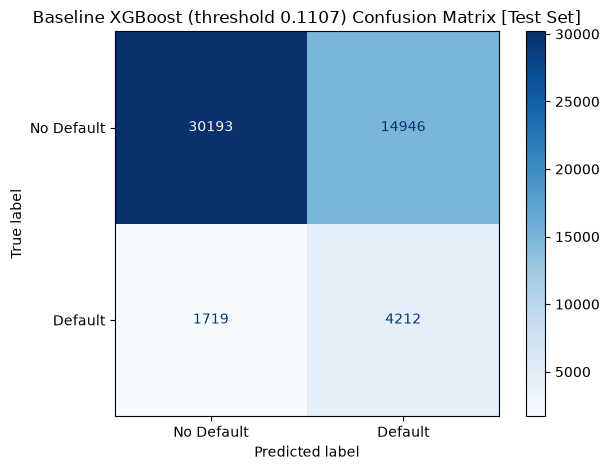

In [48]:
plot_confusion_matrix(
    y_test,
    baseline_xgb_test_predictions,
    f"Baseline XGBoost (threshold {baseline_xgb_threshold:.4f})",
)

In [49]:
optimized_test_probabilities = get_scores(best_xgb_pipeline, X_test)
optimized_test_predictions = (optimized_test_probabilities >= optimized_threshold).astype(int)
optimized_xgb_test_results = {
    "threshold": optimized_threshold,
    **evaluate_predictions(y_test, optimized_test_predictions, optimized_test_probabilities),
}
display(pd.Series(optimized_xgb_test_results))

threshold            0.484951
accuracy             0.672195
balanced_accuracy    0.687368
precision            0.218460
recall               0.707132
specificity          0.667605
f1                   0.333798
roc_auc              0.758830
average_precision    0.332784
dtype: float64

In [50]:
rf_test_probabilities = get_scores(balanced_rf_pipeline, X_test)
rf_threshold_predictions = (rf_test_probabilities >= rf_optimal_threshold).astype(int)
rf_test_results_70 = {
    "threshold": rf_optimal_threshold,
    **evaluate_predictions(y_test, rf_threshold_predictions, rf_test_probabilities),
}
display(pd.Series(rf_test_results_70))

threshold            0.227490
accuracy             0.657294
balanced_accuracy    0.681795
precision            0.211259
recall               0.713708
specificity          0.649881
f1                   0.326017
roc_auc              0.743975
average_precision    0.304879
dtype: float64

In [51]:
model_comparison = pd.DataFrame({
    "Baseline XGBoost": baseline_xgb_test_results,
    "Optimized XGBoost": optimized_xgb_test_results,
    "Balanced Random Forest": rf_test_results_70,
}).T
display(model_comparison)

,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,average_precision
Baseline XGBoost,0.110747,0.673683,0.689528,0.219856,0.710167,0.668889,0.335765,0.758987,0.332780
Optimized XGBoost,0.484951,0.672195,0.687368,0.218460,0.707132,0.667605,0.333798,0.758830,0.332784
Balanced Random Forest,0.227490,0.657294,0.681795,0.211259,0.713708,0.649881,0.326017,0.743975,0.304879


## Optimized XGBoost report and model comparison curves

In [52]:
final_classification_report = pd.DataFrame(classification_report(
    y_test, optimized_test_predictions, labels=[0, 1],
    target_names=["No Default", "Default"], output_dict=True, zero_division=0,
)).T
display(final_classification_report)

,precision,recall,f1-score,support
No Default,0.945501,0.667605,0.782615,45139.000000
Default,0.218460,0.707132,0.333798,5931.000000
accuracy,0.672195,0.672195,0.672195,0.672195
macro avg,0.581981,0.687368,0.558207,51070.000000
weighted avg,0.861066,0.672195,0.730492,51070.000000


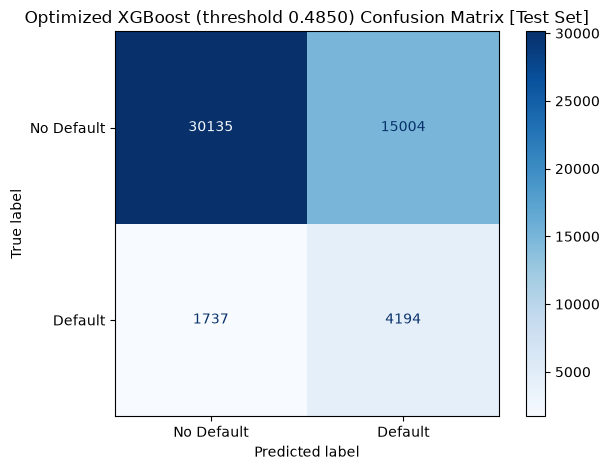

In [53]:
plot_confusion_matrix(
    y_test, optimized_test_predictions,
    f"Optimized XGBoost (threshold {optimized_threshold:.4f})",
)

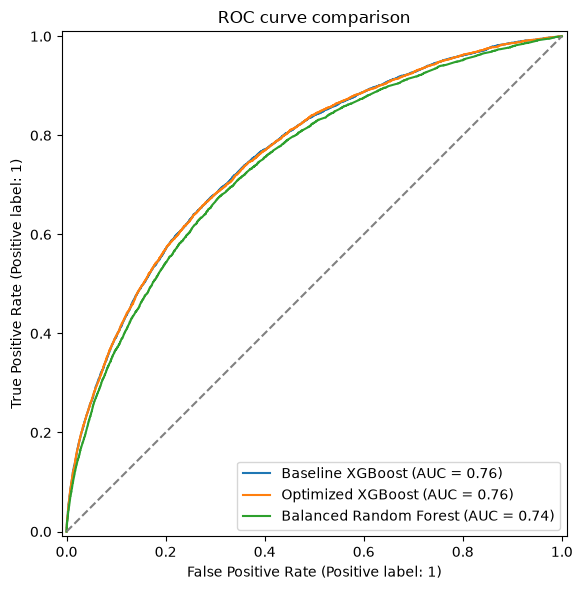

In [54]:
curve_scores = {
    "Baseline XGBoost": baseline_xgb_test_probabilities,
    "Optimized XGBoost": optimized_test_probabilities,
    "Balanced Random Forest": rf_test_probabilities,
}
fig, ax = plt.subplots(figsize=(7, 6))
for name, scores in curve_scores.items():
    RocCurveDisplay.from_predictions(y_test, scores, name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC curve comparison")
plt.tight_layout()
plt.show()

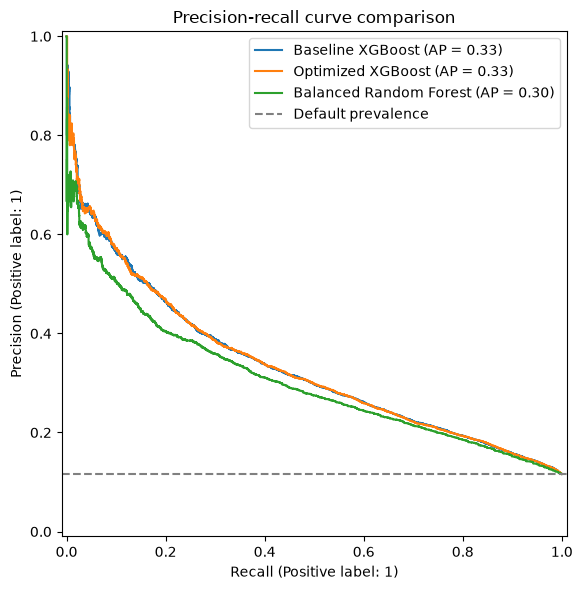

In [55]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, scores in curve_scores.items():
    PrecisionRecallDisplay.from_predictions(y_test, scores, name=name, ax=ax)
ax.axhline(y=y_test.mean(), linestyle="--", color="gray", label="Default prevalence")
ax.set_title("Precision-recall curve comparison")
ax.legend()
plt.tight_layout()
plt.show()

Although hyperparameter optimization was performed, the optimized XGBoost model did not produce a meaningful improvement over the baseline model. At thresholds selected to achieve approximately 70% recall, the baseline XGBoost recorded slightly higher accuracy, balanced accuracy, precision, F1-score, and ROC-AUC. Therefore, the baseline XGBoost with a decision threshold of 0.1107 was selected as the final model due to its comparable ranking performance, slightly better classification results, and lower complexity.

## Save and verify the selected baseline XGBoost model

In [56]:
final_credit_risk_model = {
    "pipeline": baseline_xgb_pipeline,
    "threshold": float(baseline_xgb_threshold),
    "target_recall": TARGET_RECALL,
    "model_name": "Baseline XGBoost",
    "feature_columns": X_train.columns.to_list(),
    "positive_class": 1,
}
joblib.dump(final_credit_risk_model, MODEL_PATH)

['final_credit_risk_xgboost.pkl']

In [57]:
saved_model = joblib.load(MODEL_PATH)
new_data = X_test.head(5).copy()
saved_scores = get_scores(saved_model["pipeline"], new_data)
saved_predictions = (saved_scores >= saved_model["threshold"]).astype(int)

In [58]:
np.testing.assert_allclose(saved_scores, baseline_xgb_test_probabilities[:len(new_data)])
np.testing.assert_array_equal(saved_predictions, baseline_xgb_test_predictions[:len(new_data)])
prediction_preview = pd.DataFrame({
    "actual_default": y_test.loc[new_data.index],
    "default_score": saved_scores,
    "predicted_default": saved_predictions,
}, index=new_data.index)
display(prediction_preview)

,actual_default,default_score,predicted_default
211648,0,0.043233,0
201101,0,0.022586,0
140423,0,0.063828,0
204530,0,0.134494,1
166481,0,0.072115,0
